
# การพยากรณ์ทั้งมวลพร้อมการลดขนาด

การประกอบ workflow แบบกำหนดเองพร้อมการลดขนาดแบบกำเนิดโดยใช้ CorrDiff


ตัวอย่างนี้แสดงให้เห็นถึงไปป์ไลน์ ensemble forecasting ที่รัน
Prognostic Model ensemble และใช้การลดขนาดการสร้าง CorrDiff กับแต่ละรายการ
ขั้นตอนและสมาชิก แม้ว่าตัวอย่างนี้จะใช้ SFNO สำหรับ Prognostic Model แต่
ไปป์ไลน์เป็นแบบไม่เชื่อเรื่องพระเจ้าและสามารถนำกลับมาใช้ใหม่ได้กับโมเดลพยากรณ์อื่น ๆ
ทำตามอินเทอร์เฟซ Earth2Studio

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีสร้างไปป์ไลน์ ensemble forecast พร้อมการลดขนาด CorrDiff
- บันทึกข้อมูลเอาต์พุต ensemble ไปยังที่เก็บ Zarr
- ผลลัพธ์หลังกระบวนการ


In [1]:
# /// script
# dependencies = [
#   "torch==2.9.1", # Match lock file to avoid torch-harmonics issue
#   "earth2studio[sfno] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "earth2studio[corrdiff] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การสร้างเวิร์กโฟลว์การลดขนาด Ensemble

หากต้องการสร้าง ensemble forecasting ของเราเองพร้อมการลดขนาด workflow เราจะใช้
ensemble workflow :py:meth:`earth2studio.run.ensemble` ในตัวเพื่อใช้อ้างอิงถึง
เริ่มต้นด้วย เพื่อให้ได้ผล เราจำเป็นต้องอัปเดตว่าพิกัดเอาต์พุตเป็นอย่างไร
คำนวณสำหรับวัตถุ IO รวมถึงเพิ่มการโอนสายของโมเดล CorrDiff
เข้าไปในลูป forecast

เช่นเดียวกับในตัวอย่างก่อนหน้านี้ เราใช้การพึ่งพาการฉีดเพื่อกำหนดลายเซ็นของ
วิธีการไปป์ไลน์



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from datetime import datetime
from math import ceil

import numpy as np
import torch
from loguru import logger
from tqdm import tqdm

from earth2studio.data import DataSource, fetch_data
from earth2studio.io import IOBackend
from earth2studio.models.dx import CorrDiff
from earth2studio.models.px import PrognosticModel
from earth2studio.perturbation import Perturbation
from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array


def corrdiff_on_hens_ensemble(
    time: list[str] | list[datetime] | list[np.datetime64],
    nsteps: int,
    nensemble: int,
    nsamples: int,
    prognostic: PrognosticModel,
    corrdiff: CorrDiff,
    data: DataSource,
    io: IOBackend,
    perturbation: Perturbation,
    batch_size: int | None = None,
) -> IOBackend:
    """Ensemble CorrDiff pipeline

    Parameters
    ----------
    time : list[str] | list[datetime] | list[np.datetime64]
        Forecast start times
    nsteps : int
        Number of forecast steps for prognostic model to take
    nensemble : int
        Number of forecast ensemble members
    nsamples : int
        Number of samples from CorrDiff model to generate
    prognostic : PrognosticModel
        Prognostic model
    corrdiff : CorrDiff
        CorrDiff model
    data : DataSource
        Data source
    io : IOBackend
        IO Backend
    perturbation : Perturbation
        Perturbation method
    batch_size : int | None, optional
        Ensemble batch size during forecasting. If None, uses nensemble; default None
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    prognostic = prognostic.to(device)
    corrdiff = corrdiff.to(device)
    corrdiff.number_of_samples = nsamples

    # ดึงข้อมูลเริ่มต้นสำหรับ ensemble
    prognostic_ic = prognostic.input_coords()
    time = to_time_array(time)
    x0, coords0 = fetch_data(
        source=data,
        time=time,
        variable=prognostic_ic["variable"],
        lead_time=prognostic_ic["lead_time"],
        device=device,
        interp_to=prognostic_ic if hasattr(prognostic, "interp_method") else None,
        interp_method=getattr(prognostic, "interp_method", "nearest"),
    )

    # เตรียมพิกัดเอาต์พุต CorrDiff สำหรับ IO Backend
    total_coords = corrdiff.output_coords(corrdiff.input_coords())
    if "batch" in total_coords:
        del total_coords["batch"]
    total_coords["time"] = time
    total_coords["lead_time"] = np.asarray(
        [
            prognostic.output_coords(prognostic.input_coords())["lead_time"] * i
            for i in range(nsteps + 1)
        ]
    ).flatten()
    total_coords["ensemble"] = np.arange(nensemble)
    total_coords.move_to_end("lead_time", last=False)
    total_coords.move_to_end("time", last=False)
    total_coords.move_to_end("ensemble", last=False)
    variables_to_save = total_coords.pop("variable")
    io.add_array(total_coords, variables_to_save)

    # กำหนดขนาด batch และจำนวนของ batches
    batch_size = min(nensemble, batch_size or nensemble)
    number_of_batches = ceil(nensemble / batch_size)
    logger.info(
        f"Starting {nensemble} member ensemble inference with {number_of_batches} batches."
    )

    # ลูป ensemble หลัก
    for batch_id in tqdm(
        range(0, nensemble, batch_size),
        total=number_of_batches,
        desc="Ensemble Batches",
    ):
        mini_batch_size = min(batch_size, nensemble - batch_id)
        x = x0.to(device)
        # ตั้งค่าพิกัดสำหรับ batch นี้
        coords = {
            "ensemble": np.arange(batch_id, batch_id + mini_batch_size),
            **coords0.copy(),
        }
        # ทำซ้ำเงื่อนไขเริ่มต้นสำหรับสมาชิก ensemble แต่ละตัวใน batch
        x = x.unsqueeze(0).repeat(mini_batch_size, *([1] * x.ndim))
        x, coords = map_coords(x, coords, prognostic_ic)
        x, coords = perturbation(x, coords)
        model = prognostic.create_iterator(x, coords)

        with tqdm(
            total=nsteps + 1,
            desc=f"Batch {batch_id} inference",
            position=1,
            leave=False,
        ) as pbar:
            for step, (x, coords) in enumerate(model):
                # แมปเอาต์พุตการพยากรณ์ไปยังอินพุต CorrDiff หากจำเป็น
                x, coords = map_coords(x, coords, corrdiff.input_coords())
                # CorrDiff workflow: สร้างและเขียนเอาต์พุต CorrDiff
                x, coords = corrdiff(x, coords)
                io.write(*split_coords(x, coords))
                pbar.update(1)
                if step == nsteps:
                    break

    logger.success("Inference complete")
    return io

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## การเตรียมองค์ประกอบ
เมื่อกำหนดฟังก์ชันไปป์ไลน์ inference แล้ว ต่อไปมาสร้างฟังก์ชันที่จำเป็นกัน
ส่วนประกอบต่างๆ ตามปกติ เราต้องการสิ่งต่อไปนี้:

- Prognostic Model: ใช้ SFNO รุ่น :py:class:`earth2studio.models.px.SFNO` ในตัว
- CorrDiff Model: ใช้ CorrDiff Taiwan รุ่น :py:class:`earth2studio.models.dx.CorrDiffTaiwan` ในตัว
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกผลลัพธ์ลงใน Zarr store ผ่าน :py:class:`earth2studio.io.ZarrBackend`.

สำหรับการทำนาย checkpoint เราจะใช้ HENS checkpoint เก็บไว้สะดวก
บน [กอดใบหน้า](https://huggingface.co/datasets/maheshankur10/hens/tree/main/earth2mip_prod_registry).
โปรดดูตัวอย่างก่อนหน้านี้สำหรับข้อมูลเพิ่มเติมเกี่ยวกับการโหลดโมเดลเหล่านี้



In [3]:
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.auto import Package
from earth2studio.models.dx import CorrDiffTaiwan
from earth2studio.models.px import SFNO
from earth2studio.perturbation import (
    CorrelatedSphericalGaussian,
    HemisphericCentredBredVector,
)

# สร้างแหล่งข้อมูล
data = GFS()
# โหลด Prognostic Model
hens_package = Package(
    "hf://datasets/maheshankur10/hens/earth2mip_prod_registry/sfno_linear_74chq_sc2_layers8_edim620_wstgl2-epoch70_seed103",
    cache_options={
        "cache_storage": Package.default_cache("hens_1"),
        "same_names": True,
    },
)
model = SFNO.load_model(hens_package)
# กำหนดวิธีการก่อกวน
noise_amplification = torch.zeros(model.input_coords()["variable"].shape[0])
index_z500 = list(model.input_coords()["variable"]).index("z500")
noise_amplification[index_z500] = 39.27
noise_amplification = noise_amplification.reshape(1, 1, 1, -1, 1, 1)
seed_perturbation = CorrelatedSphericalGaussian(noise_amplitude=noise_amplification)
perturbation = HemisphericCentredBredVector(
    model, data, seed_perturbation, noise_amplitude=noise_amplification
)
# โหลดโมเดล CorrDiffTaiwan
corrdiff = CorrDiffTaiwan.load_model(CorrDiffTaiwan.load_default_package())
# ตั้งค่า IO Backend
io = ZarrBackend(
    file_name="outputs/18_ensemble_corrdiff.zarr",
    chunks={"ensemble": 1, "sample": 1, "time": 1, "lead_time": 1},
    backend_kwargs={"overwrite": True},
)

## วิ่ง
ดำเนินการไปป์ไลน์ สำหรับตัวอย่างนี้ เราใช้ช่วงพายุไต้ฝุ่นดอกซูริซึ่ง
มีเส้นทางครอบคลุมภูมิภาคไต้หวัน
https://en.wikipedia.org/wiki/Typhoon_Doksuri



In [4]:
start_date = datetime(2023, 7, 26, 12)
corrdiff_on_hens_ensemble(
    time=[start_date],
    nsteps=4,
    nensemble=2,
    nsamples=3,
    prognostic=model,
    corrdiff=corrdiff,
    data=data,
    io=io,
    perturbation=perturbation,
    batch_size=1,
)

2026-04-24 15:24:45.522 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 417299170-956901
2026-04-24 15:24:45.535 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 288155822-961057
2026-04-24 15:24:45.537 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 222592109-632560
2026-04-24 15:24:45.539 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 359641141-941448
2026-04-24 15:24:45.541 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 184165363-733214
2026-04-24 15:24:45.543 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data:   0%|          | 0/74 [00:00<?, ?it/s]

2026-04-24 15:24:45.608 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 205529305-742828
2026-04-24 15:24:45.850 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 281788941-817365
2026-04-24 15:24:45.861 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 175490539-1171303
2026-04-24 15:24:45.863 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 362413948-1266593
2026-04-24 15:24:45.866 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 0-1001216
2026-04-24 15:24:45.867 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib 

Fetching GFS data: 100%|██████████| 74/74 [00:11<00:00,  6.24it/s]


2026-04-24 15:24:57.488 | INFO     | __main__:corrdiff_on_hens_ensemble:101 - Starting 2 member ensemble inference with 2 batches.


...

2026-04-24 15:24:59.574 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230725/18/atmos/gfs.t18z.pgrb2.0p25.f000 239274314-1181927
2026-04-24 15:24:59.577 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/00/atmos/gfs.t00z.pgrb2.0p25.f000 338794171-1268354
2026-04-24 15:24:59.581 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 417299170-956901
2026-04-24 15:24:59.591 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230725/18/atmos/gfs.t18z.pgrb2.0p25.f000 456673586-605114
2026-04-24 15:24:59.594 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230725/18/atmos/gfs.t18z.pgrb2.0p25.f000 177888849-957026
2026-04-24 15:24:59.597 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GF

2026-04-24 15:24:59.775 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 0-1001216
2026-04-24 15:24:59.785 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230725/18/atmos/gfs.t18z.pgrb2.0p25.f000 156135393-905044
2026-04-24 15:24:59.789 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230725/18/atmos/gfs.t18z.pgrb2.0p25.f000 361998273-583341
2026-04-24 15:24:59.791 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/00/atmos/gfs.t00z.pgrb2.0p25.f000 184567490-738404
2026-04-24 15:24:59.794 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/06/atmos/gfs.t06z.pgrb2.0p25.f000 239661414-699995
2026-04-24 15:24:59.797 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib fi

2026-04-24 15:24:59.976 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/00/atmos/gfs.t00z.pgrb2.0p25.f000 358192037-941145
2026-04-24 15:24:59.978 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/06/atmos/gfs.t06z.pgrb2.0p25.f000 363530432-939722
2026-04-24 15:24:59.981 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/12/atmos/gfs.t12z.pgrb2.0p25.f000 184898577-743713
2026-04-24 15:24:59.990 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/00/atmos/gfs.t00z.pgrb2.0p25.f000 411869505-514313
2026-04-24 15:24:59.994 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20230726/06/atmos/gfs.t06z.pgrb2.0p25.f000 420330381-531712
2026-04-24 15:24:59.996 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Ensemble Batches: 100%|██████████| 2/2 [03:06<00:00, 93.36s/it] 

2026-04-24 15:28:04.212 | SUCCESS  | __main__:corrdiff_on_hens_ensemble:140 - Inference complete


## หลังการประมวลผล
เขียนจุดเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของขนาดความเร็วลม 10 เมตรสำหรับลำดับของ
lead time



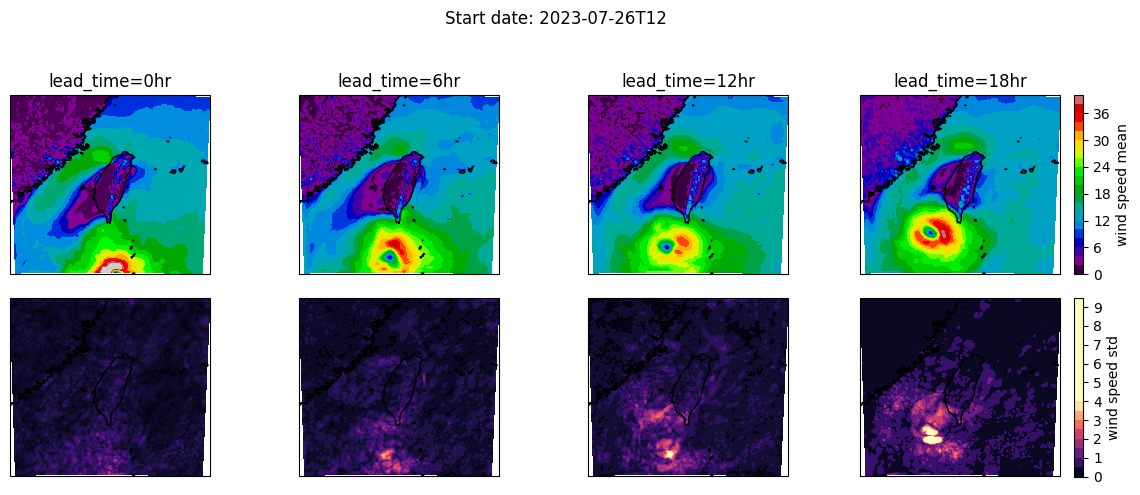

In [5]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr

ds = xr.open_zarr("outputs/18_ensemble_corrdiff.zarr")
lead_time = 4
arr = np.sqrt(ds["u10m"] ** 2 + ds["v10m"] ** 2)
mean_field = arr.mean(dim=["ensemble", "sample"])
std_field = arr.std(dim=["ensemble", "sample"])
fig, ax = plt.subplots(
    2, lead_time, figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()}
)

for i in range(lead_time):
    p1 = ax[0, i].contourf(
        ds["lon"],
        ds["lat"],
        mean_field.isel(time=0, lead_time=i),
        levels=20,
        vmin=0,
        vmax=40,
        transform=ccrs.PlateCarree(),
        cmap="nipy_spectral",
    )
    ax[0, i].coastlines()
    ax[0, i].set_title(f"lead_time={6*i}hr")

    p2 = ax[1, i].contourf(
        ds["lon"],
        ds["lat"],
        std_field.isel(time=0, lead_time=i),
        levels=20,
        vmin=0,
        vmax=4,
        transform=ccrs.PlateCarree(),
        cmap="magma",
    )
    ax[1, i].coastlines()

fig.colorbar(p1, ax=ax[0, -1], label="wind speed mean")
fig.colorbar(p2, ax=ax[1, -1], label="wind speed std")
fig.suptitle(
    f"Start date: {np.datetime_as_string(ds['time'].values[0], unit='h')}", fontsize=12
)

# เหลือพื้นที่ไว้สำหรับซับไตเติ้ล
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("outputs/18_ensemble_corrdiff_w10m.jpg")
plt.show()